# Customer Churn Notebook

In [6]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config.configuration import AppConfig
from src.pipelines.portfolio_showcase_pipeline import run_portfolio_showcase_pipeline

sns.set_theme(style='whitegrid')
assets_dir = project_root / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

config = AppConfig.from_env()
df = pd.read_csv(project_root / 'data' / 'raw' / 'telco_churn.csv')
df.head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaymentMethod,PaperlessBilling,SeniorCitizen,Partner,Dependents,Churn
0,1,29.85,29.85,Month-to-month,DSL,No,Yes,No,No,No,No,Electronic check,Yes,0,No,No,Yes
1,34,56.95,1889.50,One year,DSL,Yes,No,Yes,No,No,No,Mailed check,No,0,Yes,No,No
2,2,53.85,108.15,Month-to-month,Fiber optic,No,No,No,No,No,No,Electronic check,Yes,0,No,No,Yes
3,45,42.30,1840.75,One year,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Bank transfer,No,0,Yes,Yes,No
4,5,70.70,151.65,Month-to-month,Fiber optic,No,No,No,No,Yes,Yes,Electronic check,Yes,1,No,No,Yes


In [2]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
display(df.describe(include='all').T)

churn_dist = df['Churn'].astype(str).value_counts().rename_axis('Churn').to_frame('count')
churn_dist['ratio'] = (churn_dist['count'] / churn_dist['count'].sum()).round(4)
display(churn_dist)

Rows: 20
Columns: 17


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure,20.0,NaN,NaN,NaN,27.15,22.490407,1.0,7.25,22.0,45.75,71.0
MonthlyCharges,20.0,NaN,NaN,NaN,62.7925,24.693619,18.85,46.65,63.375,81.0625,104.2
TotalCharges,20.0,NaN,NaN,NaN,1889.945,2026.947683,29.85,351.525,1707.0,1949.65,6185.2
Contract,20,3,Month-to-month,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,20,3,Fiber optic,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,20,2,No,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,20,2,Yes,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceProtection,20,2,No,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TechSupport,20,2,No,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StreamingTV,20,2,No,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,ratio
Churn,,
Yes,11,0.55
No,9,0.45


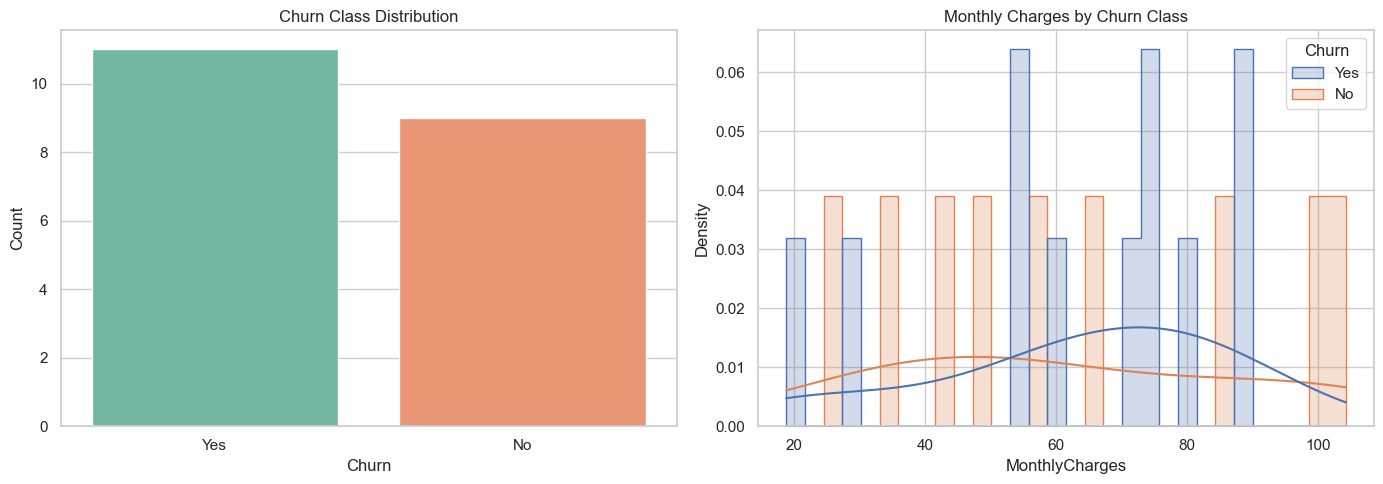

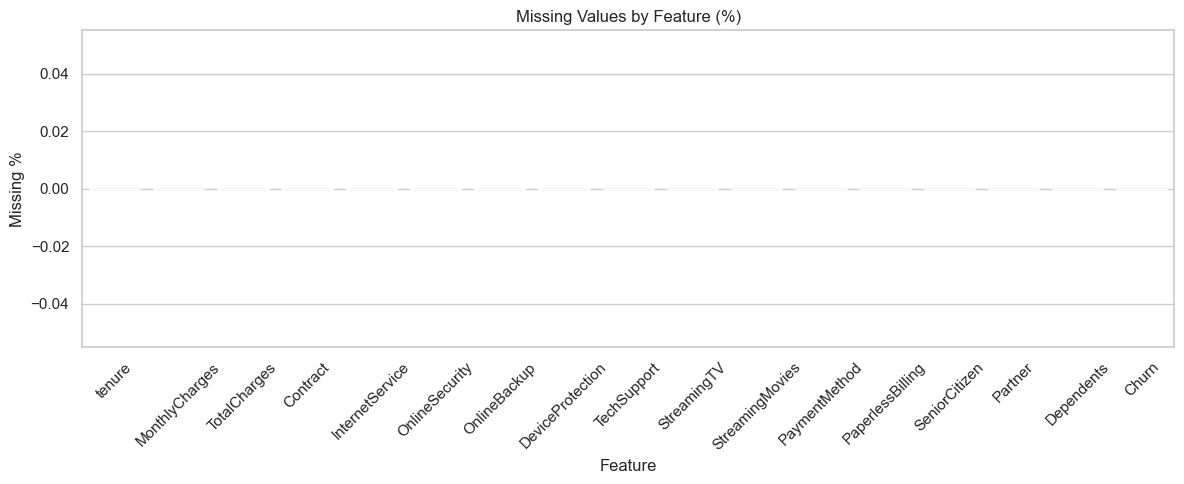

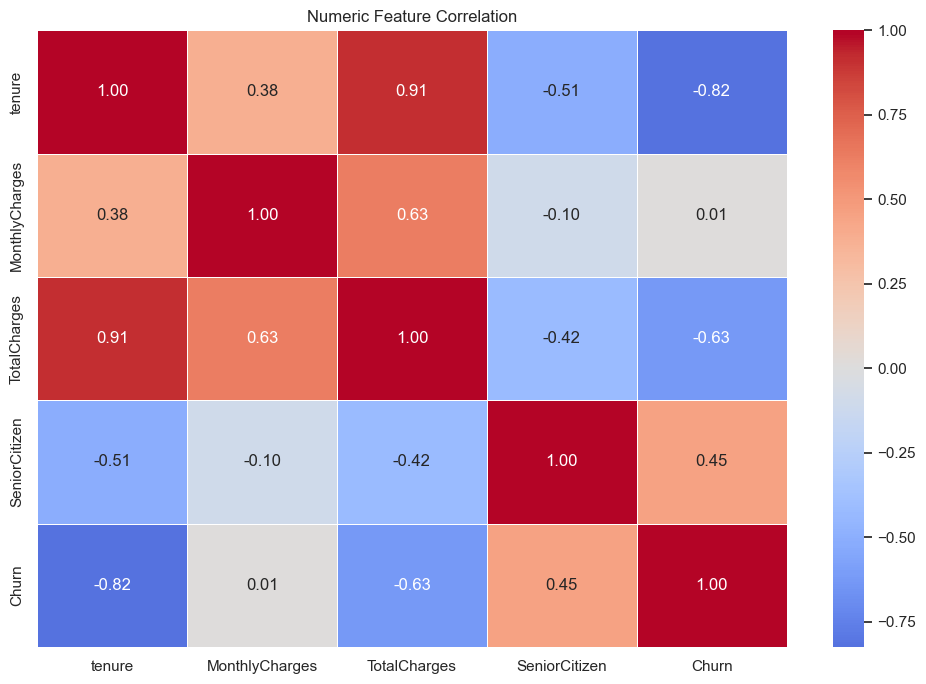

In [3]:
# EDA distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_counts = df['Churn'].astype(str).value_counts()
labels = class_counts.index.astype(str)
sns.barplot(x=labels, y=class_counts.values, hue=labels, legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('Churn Class Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Class')
axes[1].set_xlabel('MonthlyCharges')

fig.tight_layout()
fig.savefig(assets_dir / 'eda_distribution.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=missing_pct.index.astype(str), y=missing_pct.values, color='#4C78A8', ax=ax)
ax.set_title('Missing Values by Feature (%)')
ax.set_ylabel('Missing %')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(assets_dir / 'missing_values.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Correlation heatmap
corr_df = df.copy()
corr_df['Churn'] = corr_df['Churn'].astype(str).str.lower().map({'yes': 1, 'no': 0, '1': 1, '0': 0})
num_df = corr_df.select_dtypes(include=['number', 'bool'])
corr = num_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('Numeric Feature Correlation')
fig.tight_layout()
fig.savefig(assets_dir / 'correlation_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

In [4]:
# Run full showcase generation (model visuals + API visual + real outputs)
manifest = run_portfolio_showcase_pipeline(config)
manifest

2026-04-16 21:57:51 | WARNING | src.pipelines.prediction_pipeline | Aligned schema caused missing columns at inference; retrying with raw payload columns
2026-04-16 21:57:51 | WARNING | src.pipelines.prediction_pipeline | Aligned schema caused missing columns at inference; retrying with raw payload columns
2026-04-16 21:57:51 | WARNING | src.pipelines.prediction_pipeline | Aligned schema caused missing columns at inference; retrying with raw payload columns


{'assets': {'eda_distribution': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\eda_distribution.png',
  'missing_values': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\missing_values.png',
  'correlation_heatmap': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\correlation_heatmap.png',
  'model_comparison': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\model_comparison.png',
  'confusion_matrix': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\confusion_matrix.png',
  'roc_curve': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\roc_curve.png',
  'feature_importance': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\customer_churn_prediction\\assets\\feature_importance.png',
  'api_response': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projec

In [5]:
with (project_root / 'artifacts' / 'metrics.json').open('r', encoding='utf-8') as f:
    metrics = json.load(f)
with (project_root / 'artifacts' / 'output_samples.json').open('r', encoding='utf-8') as f:
    outputs = json.load(f)

display(pd.Series(metrics.get('metrics', {}), name='value').to_frame())
outputs

,value
accuracy,0.750000
precision,0.666667
recall,1.000000
f1_score,0.800000
roc_auc,1.000000


{'samples': [{'input': {'tenure': 1,
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85,
    'Contract': 'Month-to-month',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'PaymentMethod': 'Electronic check',
    'PaperlessBilling': 'Yes',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No'},
   'output': {'prediction': 'Yes', 'probability': 0.8084}},
  {'input': {'tenure': 28,
    'MonthlyCharges': 74.8,
    'TotalCharges': 2073.4,
    'Contract': 'Month-to-month',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'Yes',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'PaymentMethod': 'Electronic check',
    'PaperlessBilling': 'Yes',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No'},
   'output': 

## Churn Insights

- Churn is strongly associated with contract type, support availability, and monthly bill levels.
- Short tenure plus month-to-month profiles contribute disproportionately to high-risk predictions.
- The showcase pipeline creates all visuals and real output examples automatically for portfolio presentation.